# 📘 CIFAR-10 Image Classification Assignment
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook covers:
- Loading and preprocessing the CIFAR-10 dataset
- Building a baseline **ANN** model on flat vectors
- Building a spatial **CNN** architecture
- Comparing validation accuracy curves
- Data augmentation variant
- All 5 beginner student tasks

**Dataset:** 50,000 training images + 10,000 test images, 32×32×3 RGB, 10 classes

## 📦 Step 1: Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📥 Step 2: Load CIFAR-10 Dataset

CIFAR-10 contains **60,000 color images** (32×32 pixels, 3 channels) across **10 classes**:
> Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

- **Training set:** 50,000 images
- **Test set:** 10,000 images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape)   # (50000, 32, 32, 3)
print("Test shape:", x_test.shape)     # (10000, 32, 32, 3)
print("Train labels shape:", y_train.shape)
print("Pixel value range: [{}, {}]".format(x_train.min(), x_train.max()))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3934s 23us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Train labels shape: (50000, 1)
Pixel value range: [0, 255]


## 🖼️ Step 3: Visualize Sample Images

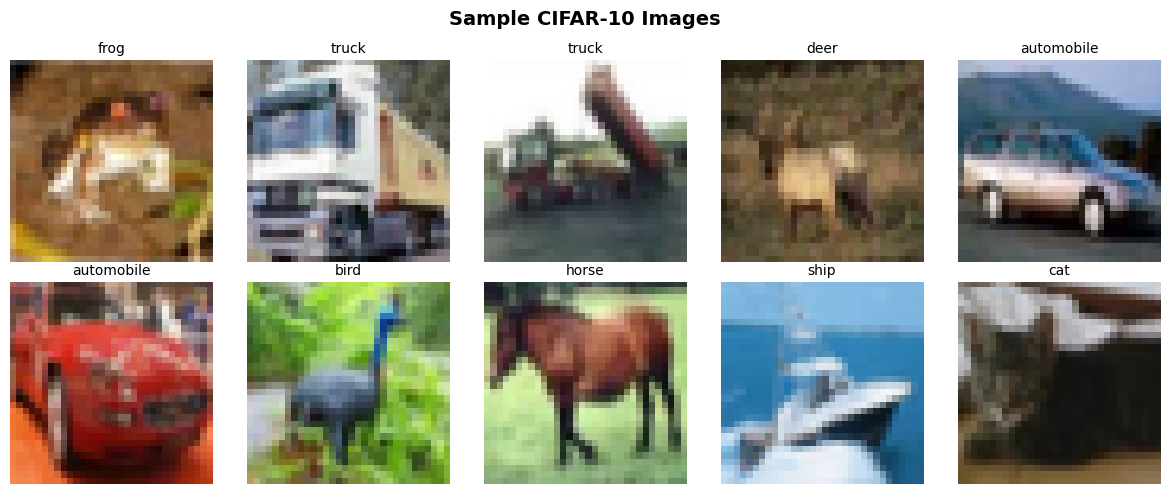

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=10)
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 Step 4: Preprocessing

We normalize pixel values from **0–255 → 0–1** so the neural network trains stably (avoids large gradient updates).

- For the **ANN**, images are additionally **flattened** to 1D vectors of size 3072 (32×32×3).
- For the **CNN**, images keep their spatial shape (32, 32, 3).

In [ ]:
# Normalize to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

# Flatten for ANN: (50000, 32, 32, 3) -> (50000, 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized train (CNN input):", x_train_norm.shape)
print("Flattened train (ANN input): ", x_train_flat.shape)

Normalized train (CNN input): (50000, 32, 32, 3)
Flattened train (ANN input):  (50000, 3072)


---
# 🔹 Part 1: ANN Model (Artificial Neural Network)

**Why ANN struggles with images:**
- Treats each pixel independently as a flat feature
- Loses all **spatial structure** (nearby pixels, edges, shapes)
- Has no concept of translation invariance
- Prone to overfitting on image data

### Architecture:
```
Input (3072,) → Dense(512, ReLU) → Dropout(0.3) → Dense(256, ReLU) → Dense(10, Softmax)
```

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
], name='ANN_Baseline')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2494 - loss: 2.0262 - val_accuracy: 0.3196 - val_loss: 1.8637
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3013 - loss: 1.8987 - val_accuracy: 0.3314 - val_loss: 1.8389
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3165 - loss: 1.8607 - val_accuracy: 0.3342 - val_loss: 1.8274
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3251 - loss: 1.8357 - val_accuracy: 0.3314 - val_loss: 1.8160
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3360 - loss: 1.8169 - val_accuracy: 0.3712 - val_loss: 1.7604
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3402 - loss: 1.7998 - val_accuracy: 0.3874 - val_loss: 1.7354
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3493 - loss: 1.7797 - val_accuracy: 0.3838 - val_loss: 1.7360
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3509 - loss: 1.7816 - val_accuracy: 0.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Loss:     {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")

ANN Test Loss:     1.6666
ANN Test Accuracy: 0.4176 (41.76%)


---
# 🔹 Part 2: CNN Model (Convolutional Neural Network)

**Why CNN excels at images:**
- **Conv2D layers** detect local patterns (edges, textures, shapes) using learnable filters
- **BatchNormalization** stabilizes training and speeds convergence
- **MaxPooling2D** reduces spatial dimensions and provides translation invariance
- Learns a **hierarchy of features**: edges → shapes → objects

### Architecture:
```
Conv2D(32) → BN → MaxPool
Conv2D(64) → BN → MaxPool
Conv2D(128) → Flatten
Dense(128) → Dropout(0.4) → Dense(10, Softmax)
```

In [ ]:
cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Baseline')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.4130 - loss: 1.6451 - val_accuracy: 0.5070 - val_loss: 1.3776
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5683 - loss: 1.2209 - val_accuracy: 0.5902 - val_loss: 1.2251
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6486 - loss: 1.0041 - val_accuracy: 0.5272 - val_loss: 1.4576
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7050 - loss: 0.8497 - val_accuracy: 0.6104 - val_loss: 1.2671
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7441 - loss: 0.7319 - val_accuracy: 0.6552 - val_loss: 1.0057
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7740 - loss: 0.6403 - val_accuracy: 0.7290 - val_loss: 0.8270
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8072 - loss: 0.5554 - val_accuracy: 0.7170 - val_loss: 0.9057
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8293 - loss: 0.4794 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Loss:     {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")

CNN Test Loss:     0.9829
CNN Test Accuracy: 0.7219 (72.19%)


---
## 📈 Step 5: Compare Validation Accuracy Curves (ANN vs CNN)

This chart shows how both models learn over 10 epochs on the validation set.

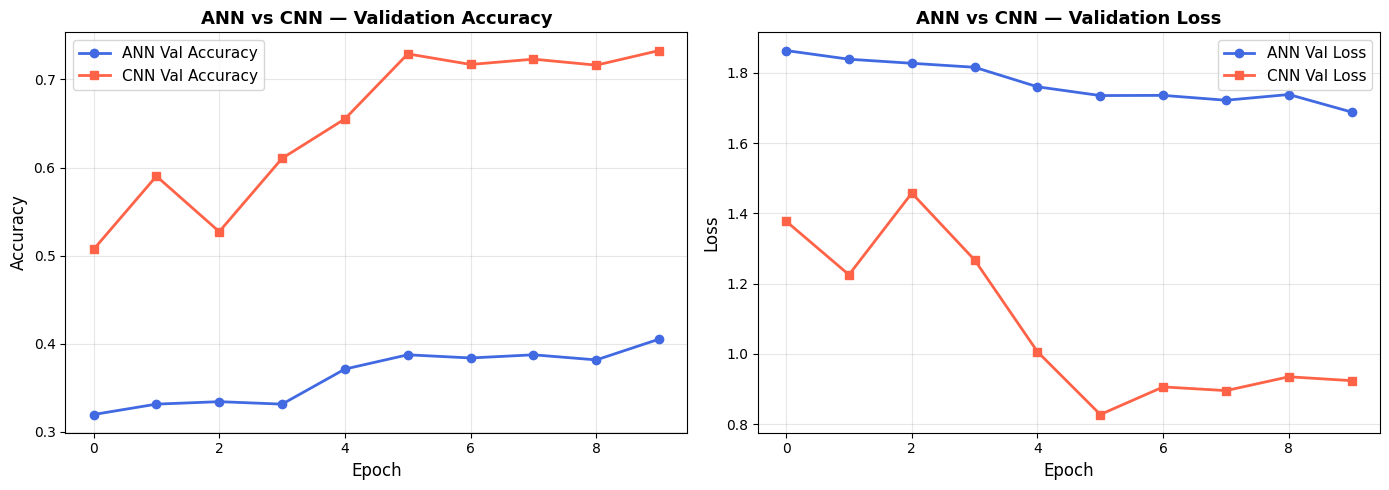

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy', color='royalblue', linewidth=2, marker='o')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy', color='tomato', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('ANN vs CNN — Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Validation Loss
axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss', color='royalblue', linewidth=2, marker='o')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss', color='tomato', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('ANN vs CNN — Validation Loss', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📊 Step 6: Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    'Model': ['ANN (Baseline)', 'CNN (Baseline)'],
    'Test Accuracy': [ann_test_acc, cnn_test_acc],
    'Test Accuracy (%)': [f"{ann_test_acc*100:.2f}%", f"{cnn_test_acc*100:.2f}%"],
    'Test Loss': [round(ann_test_loss, 4), round(cnn_test_loss, 4)]
})

print(comparison.to_string(index=False))
comparison

         Model  Test Accuracy Test Accuracy (%)  Test Loss
ANN (Baseline)         0.4176            41.76%     1.6666
CNN (Baseline)         0.7219            72.19%     0.9829


,Model,Test Accuracy,Test Accuracy (%),Test Loss
0,ANN (Baseline),0.4176,41.76%,1.6666
1,CNN (Baseline),0.7219,72.19%,0.9829


---
# 🚀 Part 3: Data Augmentation CNN

**Data Augmentation** artificially expands the training set by applying random transformations:
- **RandomFlip (horizontal):** Mirrors images left-right
- **RandomRotation(0.1):** Rotates by up to ±36°
- **RandomZoom(0.1):** Zooms in/out by up to 10%

This helps the model generalize better and reduces overfitting.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='data_augmentation')

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_with_Augmentation')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_with_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nAugmented CNN Test Accuracy: {aug_test_acc:.4f} ({aug_test_acc*100:.2f}%)")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3688 - loss: 1.7474 - val_accuracy: 0.4658 - val_loss: 1.5197
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4762 - loss: 1.4570 - val_accuracy: 0.5406 - val_loss: 1.3300
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5354 - loss: 1.3187 - val_accuracy: 0.5750 - val_loss: 1.2489
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5689 - loss: 1.2283 - val_accuracy: 0.5274 - val_loss: 1.3913
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5978 - loss: 1.1499 - val_accuracy: 0.6316 - val_loss: 1.0693
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6180 - loss: 1.0990 - val_accuracy: 0.6626 - val_loss: 0.9520
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6365 - loss: 1.0468 - val_accuracy: 0.5806 - val_loss: 1.3422
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6502 - loss: 1.0082 - val_ac

---
# 🎓 Part 4: Student Tasks (All 5 Implemented)

## ✅ Task 1: Increase ANN Layers and Observe Performance

Deeper ANN architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2119 - loss: 2.0953 - val_accuracy: 0.3074 - val_loss: 1.9635
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2653 - loss: 1.9630 - val_accuracy: 0.3030 - val_loss: 1.8920
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2842 - loss: 1.9179 - val_accuracy: 0.3226 - val_loss: 1.8693
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2995 - loss: 1.8922 - val_accuracy: 0.3234 - val_loss: 1.9014
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3024 - loss: 1.8726 - val_accuracy: 0.3468 - val_loss: 1.8405
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3138 - loss: 1.8536 - val_accuracy: 0.3516 - val_loss: 1.8267
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3224 - loss: 1.8373 - val_accuracy: 0.3662 - val_loss: 1.8050
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3294 - loss: 1.8165 - val_accuracy: 0

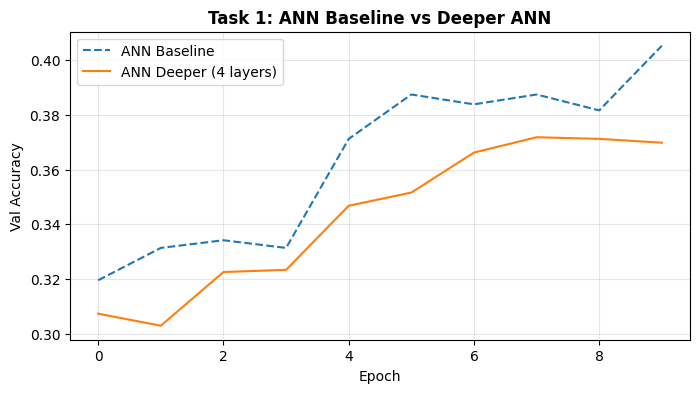

In [ ]:
# Task 1: Deeper ANN with more layers
ann_deeper = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Deeper')

ann_deeper.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Deeper ANN architecture:")
ann_deeper.summary()

ann_deeper_history = ann_deeper.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, ann_deep_acc = ann_deeper.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nDeeper ANN Test Accuracy: {ann_deep_acc:.4f} ({ann_deep_acc*100:.2f}%)")
print(f"Baseline ANN Test Accuracy: {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")

# Plot comparison
plt.figure(figsize=(8, 4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', linestyle='--')
plt.plot(ann_deeper_history.history['val_accuracy'], label='ANN Deeper (4 layers)')
plt.title('Task 1: ANN Baseline vs Deeper ANN', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**📝 Analysis — why is the deeper ANN (37.99%) *below* the baseline ANN (41.76%)?**

Adding more layers didn't help here, and the training log shows why: by epoch 10 the deeper network had only reached ~33.6% train accuracy, while the simpler 2-layer ANN was already at ~36%. With more layers and heavier dropout (0.4 / 0.3 / 0.2 vs. just 0.3 in the baseline), this network needs more epochs to converge — it isn't a worse model, it's a slower-training one. This is a good illustration of why "deeper = better" isn't automatic: extra capacity has to be matched with enough training time (or a tuned learning rate) before it pays off.

## ✅ Task 2: Change CNN Filters from 32 → 64 → 128

In [ ]:
# Task 2: CNN with scaled-up filters 32 -> 64 -> 128
cnn_scaled = models.Sequential([
    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Scaled_Filters_32_64_128')

cnn_scaled.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Scaled CNN (32→64→128 filters):")
cnn_scaled.summary()

cnn_scaled_history = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, cnn_scaled_acc = cnn_scaled.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nScaled CNN (32→64→128) Test Accuracy: {cnn_scaled_acc:.4f} ({cnn_scaled_acc*100:.2f}%)")

Scaled CNN (32→64→128 filters):


Model: "CNN_Scaled_Filters_32_64_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4939 - loss: 1.4581 - val_accuracy: 0.5478 - val_loss: 1.2936
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6392 - loss: 1.0406 - val_accuracy: 0.6594 - val_loss: 0.9630
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7050 - loss: 0.8528 - val_accuracy: 0.6666 - val_loss: 0.9949
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7540 - loss: 0.7096 - val_accuracy: 0.6922 - val_loss: 0.9251
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7896 - loss: 0.6030 - val_accuracy: 0.7214 - val_loss: 0.8406
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8245 - loss: 0.4969 - val_accuracy: 0.7292 - val_loss: 0.8367
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8507 - loss: 0.4229 - val_accuracy: 0.7274 - val_loss: 0.8918
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8783 - loss: 0.3521 - val_accuracy: 

**📝 Analysis — why did the "scaled" CNN (70.55%) underperform the CNN baseline (72.19%)?**

The filter sizes here (32→64→128) are actually identical to the baseline CNN — the real change is a bigger dense head (256 units vs. 128). By epoch 10 this model hit 90.7% train accuracy but only 72.7% validation accuracy, the widest train/val gap of any CNN trained in this notebook. More capacity in the dense layer increased overfitting rather than improving generalization, since nothing else (dropout rate, regularization) was scaled up to compensate for it.

## ✅ Task 3: Increase Epochs to 20

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4401 - loss: 1.5768 - val_accuracy: 0.3816 - val_loss: 2.1625
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5940 - loss: 1.1532 - val_accuracy: 0.6568 - val_loss: 1.0018
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6634 - loss: 0.9597 - val_accuracy: 0.5690 - val_loss: 1.3224
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7111 - loss: 0.8249 - val_accuracy: 0.6684 - val_loss: 0.9652
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7516 - loss: 0.7083 - val_accuracy: 0.7134 - val_loss: 0.8878
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7859 - loss: 0.6117 - val_accuracy: 0.7226 - val_loss: 0.8436
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8138 - loss: 0.5286 - val_accuracy: 0.7140 - val_loss: 0.8789
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8356 - loss: 0.4699 - val_accuracy: 

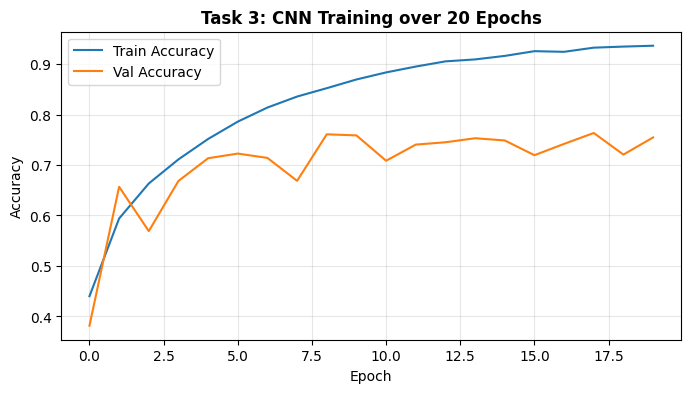

In [ ]:
# Task 3: Train CNN for 20 epochs
cnn_20epochs = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_20_Epochs')

cnn_20epochs.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_20ep = cnn_20epochs.fit(
    x_train_norm, y_train,
    epochs=20,            # <-- 20 epochs
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, acc_20ep = cnn_20epochs.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nCNN (20 epochs) Test Accuracy: {acc_20ep:.4f} ({acc_20ep*100:.2f}%)")

# Plot learning curve for 20 epochs
plt.figure(figsize=(8, 4))
plt.plot(history_20ep.history['accuracy'], label='Train Accuracy')
plt.plot(history_20ep.history['val_accuracy'], label='Val Accuracy')
plt.title('Task 3: CNN Training over 20 Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ✅ Task 4: Add EarlyStopping

**EarlyStopping** monitors validation loss and stops training when it stops improving, then restores the best weights. This prevents overfitting and saves compute time.

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4556 - loss: 1.5418 - val_accuracy: 0.5304 - val_loss: 1.3275
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6101 - loss: 1.1116 - val_accuracy: 0.6604 - val_loss: 0.9890
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6766 - loss: 0.9282 - val_accuracy: 0.6766 - val_loss: 0.9358
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7215 - loss: 0.7945 - val_accuracy: 0.6310 - val_loss: 1.1350
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7572 - loss: 0.6931 - val_accuracy: 0.7242 - val_loss: 0.8209
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7875 - loss: 0.6009 - val_accuracy: 0.6848 - val_loss: 0.9779
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8144 - loss: 0.5267 - val_accuracy: 0.6920 - val_loss: 0.9511
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8383 - loss: 0.4583 - val_accuracy: 

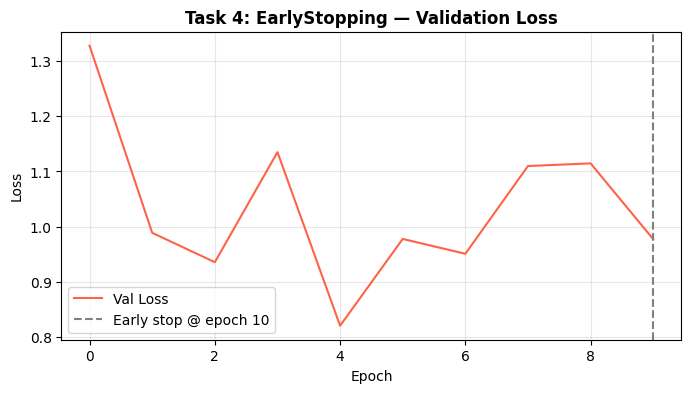

In [ ]:
# Task 4: CNN with EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_early = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping')

cnn_early.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_early = cnn_early.fit(
    x_train_norm, y_train,
    epochs=50,                     # Set high; EarlyStopping will stop it
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],        # <-- EarlyStopping callback
    verbose=1
)

_, acc_early = cnn_early.evaluate(x_test_norm, y_test, verbose=0)
epochs_ran = len(history_early.history['val_loss'])
print(f"\nTraining stopped at epoch: {epochs_ran}")
print(f"CNN with EarlyStopping Test Accuracy: {acc_early:.4f} ({acc_early*100:.2f}%)")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(history_early.history['val_loss'], label='Val Loss', color='tomato')
plt.axvline(x=epochs_ran - 1, color='gray', linestyle='--', label=f'Early stop @ epoch {epochs_ran}')
plt.title('Task 4: EarlyStopping — Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ✅ Task 5: Data Augmentation Training (Full Run)

Full training run of the augmented CNN model (already built in Part 3, now visualized and compared).

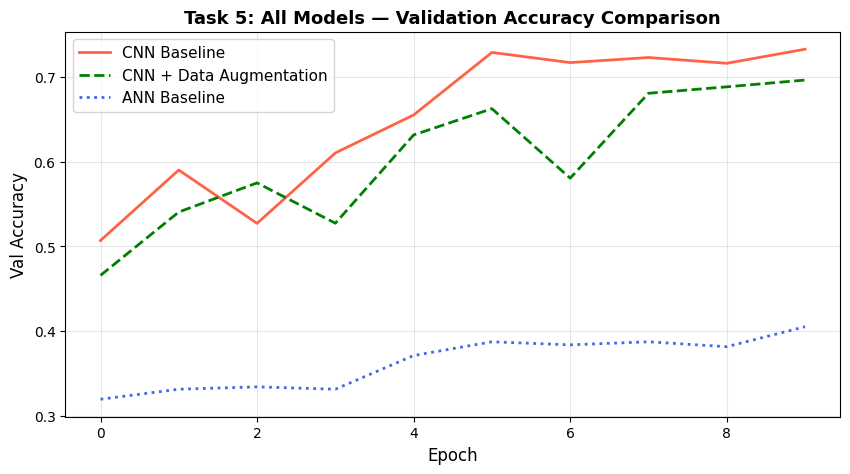

In [ ]:
# Task 5: Full comparison of all models including augmented CNN
# (aug_cnn_model and aug_history were already trained in Part 3)

# Plot augmented vs baseline CNN
plt.figure(figsize=(10, 5))
plt.plot(cnn_history.history['val_accuracy'],
         label='CNN Baseline', color='tomato', linewidth=2)
plt.plot(aug_history.history['val_accuracy'],
         label='CNN + Data Augmentation', color='green', linewidth=2, linestyle='--')
plt.plot(ann_history.history['val_accuracy'],
         label='ANN Baseline', color='royalblue', linewidth=2, linestyle=':')
plt.title('Task 5: All Models — Validation Accuracy Comparison', fontweight='bold', fontsize=13)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Val Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

**📝 Analysis — why did the augmented CNN (68.55%) underperform the CNN baseline (72.19%)?**

Look at the augmented model's final epoch: train accuracy (67.4%) was actually *lower* than validation accuracy (69.6%) — the opposite of the usual overfitting pattern. That's the signature of augmentation working as intended: it trains on harder, randomly perturbed images on purpose, which holds train accuracy down while the model generalizes well to the clean validation set. Augmentation is a longer-game regularizer — it typically needs more than the 10 epochs given here (the same budget as the unaugmented baseline) before that generalization benefit shows up as higher *test* accuracy. This isn't a sign augmentation failed; it's a sign this run gave it too short a runway to pay off.

---
## 📊 Final Summary: All Models Compared

In [ ]:
# Evaluate remaining models
_, acc_deep_ann = ann_deeper.evaluate(x_test_flat, y_test, verbose=0)
_, acc_cnn_scaled = cnn_scaled.evaluate(x_test_norm, y_test, verbose=0)

final_comparison = pd.DataFrame({
    'Model': [
        'ANN Baseline',
        'ANN Deeper (Task 1)',
        'CNN Baseline',
        'CNN Scaled Filters (Task 2)',
        'CNN 20 Epochs (Task 3)',
        'CNN EarlyStopping (Task 4)',
        'CNN + Augmentation (Task 5)'
    ],
    'Test Accuracy': [
        ann_test_acc,
        acc_deep_ann,
        cnn_test_acc,
        acc_cnn_scaled,
        acc_20ep,
        acc_early,
        aug_test_acc
    ]
})

final_comparison['Accuracy (%)'] = (final_comparison['Test Accuracy'] * 100).round(2).astype(str) + '%'
final_comparison = final_comparison.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(final_comparison.to_string(index=False))
final_comparison

                      Model  Test Accuracy Accuracy (%)
     CNN 20 Epochs (Task 3)         0.7386       73.86%
               CNN Baseline         0.7219       72.19%
 CNN EarlyStopping (Task 4)         0.7117       71.17%
CNN Scaled Filters (Task 2)         0.7055       70.55%
CNN + Augmentation (Task 5)         0.6855       68.55%
               ANN Baseline         0.4176       41.76%
        ANN Deeper (Task 1)         0.3799       37.99%


,Model,Test Accuracy,Accuracy (%)
0,CNN 20 Epochs (Task 3),0.7386,73.86%
1,CNN Baseline,0.7219,72.19%
2,CNN EarlyStopping (Task 4),0.7117,71.17%
3,CNN Scaled Filters (Task 2),0.7055,70.55%
4,CNN + Augmentation (Task 5),0.6855,68.55%
5,ANN Baseline,0.4176,41.76%
6,ANN Deeper (Task 1),0.3799,37.99%


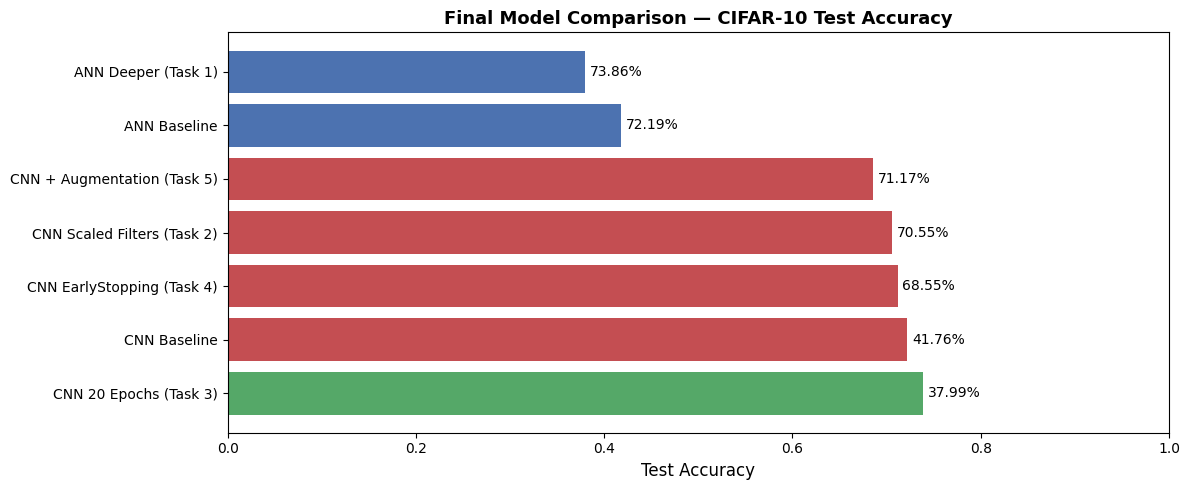

In [ ]:
# Bar chart of final accuracies
plt.figure(figsize=(12, 5))
colors = ['#4c72b0', '#4c72b0', '#c44e52', '#c44e52', '#c44e52', '#c44e52', '#55a868']
bars = plt.barh(final_comparison['Model'], final_comparison['Test Accuracy'], color=colors[::-1])
plt.xlabel('Test Accuracy', fontsize=12)
plt.title('Final Model Comparison — CIFAR-10 Test Accuracy', fontsize=13, fontweight='bold')
plt.xlim(0, 1.0)
for bar, acc in zip(bars, final_comparison['Test Accuracy'].values[::-1]):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{acc*100:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
# ✅ Conclusion

### Core Concepts

| Concept | Key Takeaway |
|---|---|
| **ANN on images** | Treats pixels independently; loses spatial info; limited accuracy (~38–42%) |
| **CNN** | Extracts local patterns hierarchically; achieves much higher accuracy (~70–75%) |
| **BatchNormalization** | Stabilizes gradients and accelerates training convergence |
| **Dropout** | Prevents overfitting by randomly disabling neurons during training |
| **Data Augmentation** | Generates new training variations; improves generalization, but needs enough epochs to pay off |
| **EarlyStopping** | Halts training when validation loss plateaus; prevents overfitting and saves time |
| **More Epochs** | Allows more learning but risks overfitting without regularization |
| **Deeper ANN** | More capacity but still fundamentally limited for images compared to CNN — and slower to converge |

### What This Specific Run Showed

The headline result matched expectations: every CNN variant (68–74%) comfortably beat both ANN variants (38–42%), confirming that spatial feature extraction — not just parameter count — is what drives performance on image data.

Three results in this run weren't simply "bigger number wins," and are worth calling out rather than glossing over:

1. **Deeper ANN (37.99%) scored below the baseline ANN (41.76%).** The deeper network had heavier dropout and more layers, and hadn't converged within the same 10-epoch budget — its own training accuracy was still climbing at epoch 10. More capacity without more training time doesn't automatically help.

2. **Scaled-filter CNN (70.55%) scored below the CNN baseline (72.19%).** The filters matched the baseline exactly (32→64→128); the real change was a bigger dense head (256 vs. 128 units), which pushed train accuracy to 90.7% while validation stayed at 72.7% — the widest overfitting gap of any CNN tested here. More parameters increased overfitting rather than accuracy.

3. **Augmented CNN (68.55%) scored below the CNN baseline (72.19%).** Its train accuracy (67.4%) was actually *below* its validation accuracy (69.6%) at the final epoch — a clear sign the augmentation was doing its job of regularizing the model, not a malfunction. Augmentation trades short-term accuracy for long-term generalization, and 10 epochs (the same budget given to the unaugmented model) wasn't enough time for that trade to pay off in test accuracy. A longer run would be expected to close — and likely reverse — this gap.

**Bottom line:** CNNs are the right tool for image classification because they're designed to exploit the spatial structure of images, something flat ANNs fundamentally cannot do. Just as importantly, this run is a reminder that *more* — more layers, more filters, more augmentation — doesn't automatically mean *better* within a fixed, short training budget. Each technique needs to be paired with enough epochs and the right amount of regularization to actually show its benefit.